# 第 11 章 · 出租车调度 Q-learning 代码实验

本页让智能体学习接乘客、送乘客。每一步都会产生奖励或惩罚，Q-learning 用这些反馈更新“在某个状态做某个动作”的价值。

[章节网页](../ch11.html)

## 运行内容

- 加载出租车调度任务
- 记录 TD target 和 TD error
- 绘制回报与 Q 表

## 0. 出租车任务

先训练 Q 表，再看抽样 TD 更新和回报曲线。最后渲染一个状态，查看当前 Q 表建议哪个动作。

In [1]:
# 载入本页会用到的数据集、模型和绘图工具。
import importlib.util
import logging
import math
import subprocess
import sys
import warnings
from collections import Counter, defaultdict
from pathlib import Path

required_packages = {
    "numpy": "numpy>=1.24",
    "pandas": "pandas>=2.0",
    "matplotlib": "matplotlib>=3.7",
    "scipy": "scipy>=1.10",
    "sklearn": "scikit-learn>=1.3",
}
missing = [package for module, package in required_packages.items() if importlib.util.find_spec(module) is None]
if missing:
    subprocess.check_call([sys.executable, "-m", "pip", "install", *missing])

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
from PIL import Image
from IPython.display import display
from scipy.optimize import dual_annealing
from scipy.signal import correlate2d
from sklearn.datasets import load_digits, load_iris, load_sample_image, make_moons
from sklearn.decomposition import TruncatedSVD
from sklearn.metrics import accuracy_score, confusion_matrix, log_loss, mean_squared_error
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.model_selection import cross_val_score, train_test_split
from sklearn.neural_network import MLPClassifier, MLPRegressor
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler, normalize
from sklearn.svm import SVC

font_paths = [
    "/usr/share/fonts/opentype/noto/NotoSansCJK-Regular.ttc",
    "/usr/share/fonts/opentype/noto/NotoSansCJK-Bold.ttc",
    "/System/Library/Fonts/Supplemental/Arial Unicode.ttf",
    "/Library/Fonts/Arial Unicode.ttf",
    "/System/Library/Fonts/STHeiti Medium.ttc",
    "/System/Library/Fonts/STHeiti Light.ttc",
]
font_name = "DejaVu Sans"
for path in font_paths:
    if Path(path).exists():
        fm.fontManager.addfont(path)
        font_name = fm.FontProperties(fname=path).get_name()
        break

logging.getLogger("matplotlib.font_manager").setLevel(logging.ERROR)
warnings.filterwarnings("ignore")
plt.rcParams.update({
    "figure.dpi": 110,
    "axes.unicode_minus": False,
    "font.family": "sans-serif",
    "font.sans-serif": [font_name, "DejaVu Sans", "sans-serif"],
})

In [2]:
# 载入强化学习经典环境。
if importlib.util.find_spec("gymnasium") is None:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "gymnasium>=0.29"])

import gymnasium as gym

In [3]:
# 出租车调度：用 Q-learning 展示 TD target 和 Q 表更新。
def make_taxi_env():
    for env_id in ("Taxi-v4", "Taxi-v3"):
        try:
            return gym.make(env_id, render_mode="ansi")
        except Exception:
            continue
    raise RuntimeError("Taxi environment is unavailable.")


taxi_env = make_taxi_env()
n_states_taxi = taxi_env.observation_space.n
n_actions_taxi = taxi_env.action_space.n
Q_taxi = np.zeros((n_states_taxi, n_actions_taxi))
alpha = 0.15
gamma = 0.95
epsilon_start = 1.0
epsilon_end = 0.05
episodes = 1600
rng = np.random.default_rng(11)
training_rows = []
td_samples = []

for episode in range(1, episodes + 1):
    state, _ = taxi_env.reset(seed=episode)
    total_reward = 0
    steps = 0
    epsilon = max(epsilon_end, epsilon_start * (0.995 ** episode))
    terminated = truncated = False

    while not (terminated or truncated) and steps < 200:
        if rng.random() < epsilon:
            action = taxi_env.action_space.sample()
        else:
            action = int(np.argmax(Q_taxi[state]))
        next_state, reward, terminated, truncated, _ = taxi_env.step(action)
        td_target = reward + gamma * np.max(Q_taxi[next_state]) * (not (terminated or truncated))
        td_error = td_target - Q_taxi[state, action]
        Q_taxi[state, action] += alpha * td_error
        if len(td_samples) < 12:
            td_samples.append({
                "episode": episode,
                "state": state,
                "action": action,
                "reward": reward,
                "next_state": next_state,
                "TD target": td_target,
                "TD error": td_error,
            })
        state = next_state
        total_reward += reward
        steps += 1

    if episode % 100 == 0:
        training_rows.append({"episode": episode, "reward": total_reward, "steps": steps, "epsilon": epsilon})

taxi_trace = pd.DataFrame(training_rows)
td_trace = pd.DataFrame(td_samples).round(3)
display(td_trace)
display(taxi_trace.tail(8).round(3))

,episode,state,action,reward,next_state,TD target,TD error
0,1,252,1,-1,152,-1.0,-1.00
1,1,152,3,-1,152,-1.0,-1.00
2,1,152,0,-1,252,-1.0,-1.00
3,1,252,4,-10,252,-10.0,-10.00
4,1,252,1,-1,152,-1.0,-0.85
5,1,152,1,-1,52,-1.0,-1.00
6,1,52,5,-10,52,-10.0,-10.00
7,1,52,1,-1,52,-1.0,-1.00
8,1,52,2,-1,72,-1.0,-1.00
9,1,72,2,-1,92,-1.0,-1.00


,episode,reward,steps,epsilon
8,900,15,6,0.05
9,1000,-4,16,0.05
10,1100,8,13,0.05
11,1200,12,9,0.05
12,1300,-3,15,0.05
13,1400,9,12,0.05
14,1500,7,14,0.05
15,1600,9,12,0.05


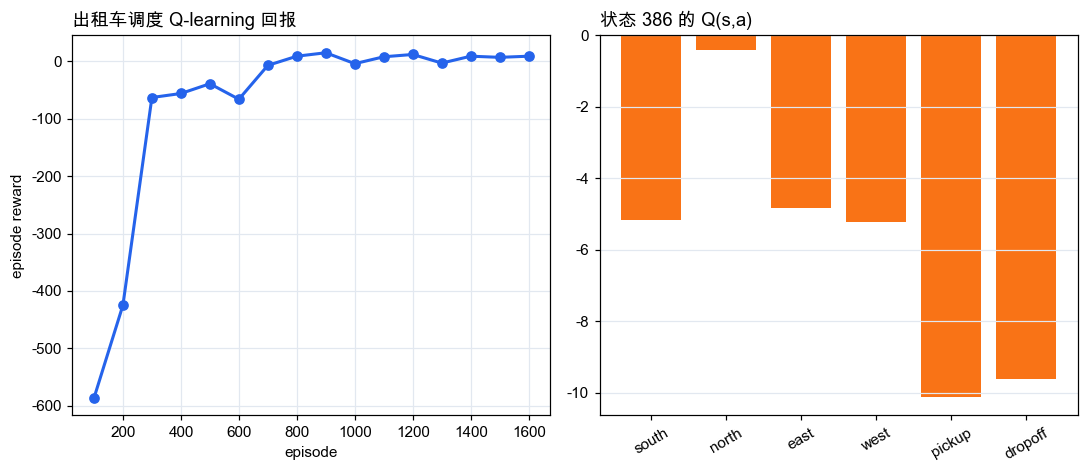

+---------+
|R: | : :G|
| : | : : |
| : : : : |
| | : | : |
|Y| : |B: |
+---------+


greedy action at rendered state: north


In [4]:
# 绘制训练曲线和一个起始状态的动作价值。
start_state, _ = taxi_env.reset(seed=42)
fig, axes = plt.subplots(1, 2, figsize=(10.0, 4.4))
axes[0].plot(taxi_trace["episode"], taxi_trace["reward"], marker="o", color="#2563eb", linewidth=2.0)
axes[0].set_title("出租车调度 Q-learning 回报", loc="left", fontweight="bold")
axes[0].set_xlabel("episode")
axes[0].set_ylabel("episode reward")
axes[0].grid(True, color="#e2e8f0", linewidth=0.8)

action_labels = ["south", "north", "east", "west", "pickup", "dropoff"]
axes[1].bar(action_labels, Q_taxi[start_state], color="#f97316")
axes[1].set_title(f"状态 {start_state} 的 Q(s,a)", loc="left", fontweight="bold")
axes[1].tick_params(axis="x", rotation=30)
axes[1].grid(True, axis="y", color="#e2e8f0", linewidth=0.8)
plt.tight_layout()
plt.show()
print(taxi_env.render())
print("greedy action at rendered state:", action_labels[int(np.argmax(Q_taxi[start_state]))])
taxi_env.close()